<a href="https://colab.research.google.com/github/NishanRegmi/Deep-Learning/blob/main/weight_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/ushape.csv')

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


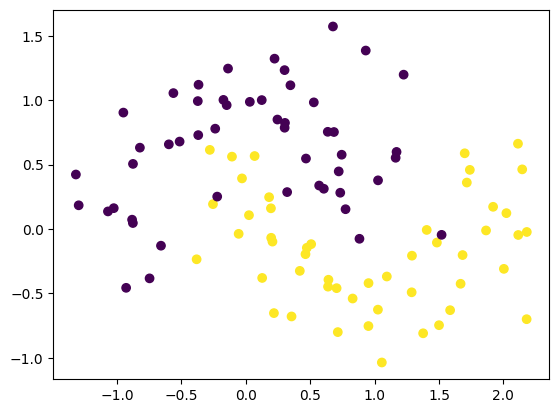

In [4]:
plt.scatter(df['X'], df['Y'], c=df['class'])
plt.show()

In [21]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

In [22]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

In [8]:
model.add(Dense(10, activation='tanh', input_dim=2))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
initial_weights = model.get_weights()

In [11]:
initial_weights

[array([[ 0.01003063,  0.649442  , -0.28884026,  0.5553897 , -0.67830443,
         -0.4943198 , -0.5841838 ,  0.04541659,  0.27967066,  0.37181002],
        [ 0.32124394,  0.5929553 , -0.45131013,  0.42515868,  0.55325824,
          0.43528098, -0.51252425,  0.49821895, -0.6951133 ,  0.16782421]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.29344442, -0.37373704, -0.39142025, -0.3260138 , -0.24182719,
         -0.405941  , -0.4670053 , -0.44550294,  0.35967577, -0.42608553],
        [ 0.26678675,  0.19680971,  0.09130543, -0.41444522, -0.25319052,
         -0.10801327,  0.18253314, -0.14678764,  0.2874537 , -0.11626548],
        [ 0.43289083, -0.38130718,  0.5442196 , -0.06204084,  0.439723  ,
          0.34541655, -0.4776628 ,  0.34176075,  0.30476618, -0.2080073 ],
        [-0.350022  , -0.18407303,  0.15935951,  0.10469937, -0.14187714,
          0.17512059,  0.38630515, -0.31530693,  0.48331392, -0.05013373],
        [-0.20529

In [12]:
initial_weights[0] = np.random.randn(2, 10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.rand(10, 10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10, 10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10, 10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10, 1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [13]:
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[-1.45186111e-01, -1.46372271e+00,  1.04592755e-01,
          4.28948253e-02, -1.44381881e+00,  1.13209374e-01,
          8.23753655e-01, -2.67521262e-01,  1.77281827e-01,
         -7.42178485e-02],
        [ 1.71528482e+00,  3.06390017e-01,  3.56569052e-01,
         -2.36548632e-01, -7.81310320e-01, -4.14632738e-01,
          3.13709438e-01, -5.35065234e-01,  1.62681783e-04,
         -6.86126769e-01]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[1.73269466e-01, 1.79009184e-01, 2.47892186e-01, 1.66481540e-01,
         2.09828317e-01, 1.88076447e-04, 2.83332467e-01, 1.71008036e-01,
         2.99120307e-01, 2.07515851e-01],
        [8.09886754e-02, 3.10843676e-01, 4.18272801e-02, 2.73909032e-01,
         2.25633278e-01, 2.47008547e-01, 3.00420225e-01, 2.40264118e-01,
         6.03422113e-02, 2.37277374e-01],
        [6.74221218e-02, 6.78792149e-02, 8.83863345e-02, 1.63211599e-01,
         2.78705060e-01, 1.84375226e-01, 1.74504921e-01

In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=False)

In [17]:
model.get_weights()

[array([[-0.30596387, -1.2337561 , -0.03764891,  0.22332665, -1.4071211 ,
          0.15921097,  0.98295337, -0.26782367,  0.29591247, -0.14104383],
        [ 1.7165736 ,  0.40706086,  0.4467003 , -0.25567535, -0.78001976,
         -0.35686347,  0.3945635 , -0.4648514 ,  0.03772577, -0.6203504 ]],
       dtype=float32),
 array([-0.04413509, -0.03656652,  0.00256484,  0.07190744, -0.20415847,
         0.05869512, -0.08896357,  0.06939672,  0.03393547, -0.00204316],
       dtype=float32),
 array([[ 0.25382146,  0.2623232 ,  0.16762757,  0.09947593,  0.2767281 ,
          0.08067475,  0.3633942 ,  0.2636022 ,  0.2738036 ,  0.215777  ],
        [ 0.06384218,  0.300071  ,  0.04448598,  0.29499805,  0.13457212,
          0.23907629,  0.2610218 ,  0.24077953, -0.05027077,  0.17935881],
        [ 0.15013443,  0.15087351,  0.00253287,  0.09125327,  0.372792  ,
          0.26601014,  0.255826  ,  0.33149123,  0.11253479,  0.21166828],
        [-0.13404775, -0.06237864,  0.39866367,  0.22537005, 

In [18]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


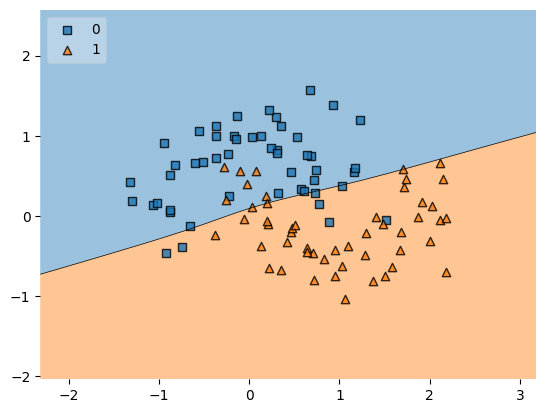

In [19]:
plot_decision_regions(X, y.astype(int), clf=model, legend=2)
plt.show()

We get the better result due to the proper weight initialization. We used Xavier/Glorat initialization technique and activation function is tanh.

**weight initialization using keras**

In [31]:
model = Sequential()

In [32]:
model.add(Dense(10, activation='relu', input_dim=2, kernel_initializer='he_uniform'))
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1, activation='sigmoid'))

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.get_weights()

[array([[ 1.6433096e-01, -1.2194860e+00, -1.5354372e+00, -8.4702337e-01,
          2.3445117e-01,  1.6201340e+00, -4.9606943e-01,  5.5924952e-01,
         -7.9541290e-01,  6.5351474e-01],
        [-1.1829301e+00, -1.7123227e+00,  8.4033978e-01, -7.2145462e-04,
          1.6790661e+00, -1.3640249e-01, -1.3842601e+00, -1.5674733e+00,
         -3.3724308e-01, -1.2973124e+00]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.15926301,  0.12117088, -0.16146994, -0.41588506,  0.10599864,
         -0.48335448,  0.6054722 ,  0.75536394, -0.10922056, -0.6655994 ],
        [ 0.6575465 ,  0.53780997, -0.23146129, -0.77233934, -0.31809074,
         -0.48111287, -0.18375188,  0.33398318, -0.5440211 ,  0.01110971],
        [-0.5335502 ,  0.13642734, -0.12670904, -0.28613955,  0.37599635,
          0.6961243 ,  0.5024439 ,  0.4148929 , -0.06687272,  0.6714214 ],
        [ 0.50158644, -0.2720713 ,  0.6737915 , -0.75428504,  0.3856349 ,
         -0.03388292,

In [34]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=False)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


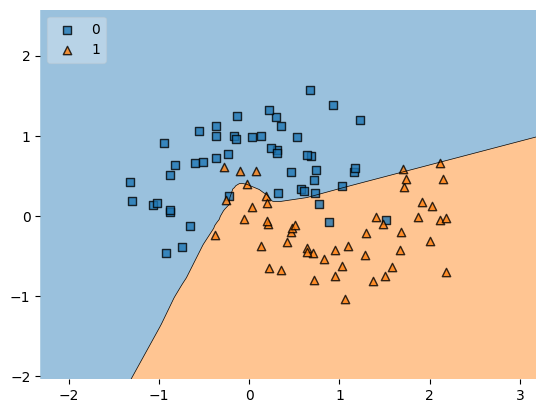

In [36]:
plot_decision_regions(X, y.astype(int), clf=model, legend=2)
plt.show()

This is how we implemnet the weight initialization technique using keras.